# Assignment 8 — Model Answer: Robustness Analysis

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  

> **Pre-requisite:** Assignment 7 (Pareto front visualisation). The cross-seed reference set from Assignment 6 is required.

---

## Learning Outcomes

After completing this assignment you will be able to:

1. Explain why policies optimised under a small scenario set may be fragile, and what re-evaluation across a larger ensemble reveals.
2. Run the JUSTICE model programmatically for a given policy and a given FAIR ensemble member, and extract the four objective values.
3. Organise results into a `(n_policies × n_scenarios × n_objectives)` array and compute robustness metrics from it.
4. Compute and interpret **satisficing scores** and **minimax regret** correctly — including the distinction between per-scenario regret and the maximum regret across scenarios.
5. Identify the minimax-regret policy and articulate its trade-offs relative to the full Pareto front.

## Setup — Imports, paths, and model constants

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as _mpath
import seaborn as sns
from IPython.display import display
from tqdm.notebook import tqdm   # progress bar; pip install tqdm if missing

# ── Patch matplotlib Path deepcopy ────────────────────────────────────────────
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib; matplotlib.use("Agg")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))
RESULTS_ROOT  = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results"))
_CONFIG_DIR   = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../config"))
_PLOTS_DIR    = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

# JUSTICE data loaders use relative paths; must run from JUSTICE root.
os.chdir(_JUSTICE_ROOT)

# ── JUSTICE imports ───────────────────────────────────────────────────────────
from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import Abatement, DamageFunction, Economy, WelfareFunction
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from justice.objectives.objective_functions import years_above_temperature_threshold
from solvers.emodps.rbf import RBF

# ── Config ────────────────────────────────────────────────────────────────────
with open(os.path.join(_CONFIG_DIR, "config_ssp245.json")) as fh:
    _cfg = json.load(fh)

_time_horizon = TimeHorizon(
    start_year=_cfg["start_year"],
    end_year=_cfg["end_year"],
    data_timestep=_cfg["data_timestep"],
    timestep=_cfg["timestep"],
)

N_TIMESTEPS = len(_time_horizon.model_time_horizon)   # 286 (2015–2300, 1-yr steps)
N_REGIONS   = len(DataLoader().REGION_LIST)           # 57 RICE50 regions
N_INPUTS    = _cfg["n_inputs"]                        # 2 (temperature, rate of change)
N_RBFS      = N_INPUTS + 2                            # 4
SCENARIO    = _cfg["reference_ssp_rcp_scenario_index"]  # 2 = SSP2-RCP4.5

EC_START_TS = _time_horizon.year_to_timestep(
    year=_cfg["emission_control_start_year"],
    timestep=_cfg["timestep"],
)

# RBF parameter shapes (needed to slice policy rows correctly)
_rbf_tmp = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS, n_outputs=N_REGIONS)
C_SHAPE, R_SHAPE, W_SHAPE = _rbf_tmp.get_shape()

# Scaling constants for RBF inputs
_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF =  2.0, 0.0

OBJECTIVES = ["welfare", "years_above_2C", "welfare_loss_damage", "welfare_loss_abatement"]
OBJ_LABELS = ["Welfare", "Yrs > 2°C", "WL Damage", "WL Abatement"]

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_ROOT}")
print(f"N_TIMESTEPS  : {N_TIMESTEPS}")
print(f"N_REGIONS    : {N_REGIONS}")
print("Setup OK")


JUSTICE root : /Users/jzatarinsalaza/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/epa141a-MBDM/epa141a/JUSTICE-main
Results root : /Users/jzatarinsalaza/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/epa141a-MBDM/epa141a/model_answers_ema/results
N_TIMESTEPS  : 286
N_REGIONS    : 57
Setup OK


---

## Step 1 — Load the reference set from Assignment 6

The re-evaluation starts from the **cross-seed reference set** built in Assignment 6: `results/reference_set_utilitarian.csv`. This is the epsilon-nondominated set pooled across all seeds — the best Pareto approximation available from the optimisation.

We extract the **lever columns** (RBF parameters) from the objective columns, since we need to reconstruct the policy for each JUSTICE run.

In [2]:
# ── Load reference set ────────────────────────────────────────────────────────
# Primary: cross-seed reference set from Assignment 6
REF_SET_PATH = os.path.join(RESULTS_ROOT, "reference_set_utilitarian.csv")

# Fallback: pre-computed reference set in data_for_reproducibility/
if not os.path.exists(REF_SET_PATH):
    REF_SET_PATH = os.path.join(
        RESULTS_ROOT, "UTILITARIAN_reference_set.csv"
    )
    print(f"Assignment 6 output not found — using pre-computed reference set.")

ref_set = pd.read_csv(REF_SET_PATH)
# Drop any penalty solutions (welfare > 1e5 signals a failed evaluation)
ref_set = ref_set[ref_set["welfare"] < 1e5].reset_index(drop=True)

# Identify lever vs objective columns
OPT_OBJECTIVES = ["welfare", "fraction_above_threshold",
                  "welfare_loss_damage", "welfare_loss_abatement"]
LEVER_COLS = [c for c in ref_set.columns if c not in OPT_OBJECTIVES]

print(f"Reference set loaded from: {REF_SET_PATH}")
print(f"  {len(ref_set)} policies  |  {len(LEVER_COLS)} lever columns")
print(f"  Lever columns (first 5): {LEVER_COLS[:5]}")
print()
print("Optimisation objective ranges:")
print(ref_set[OPT_OBJECTIVES].describe().round(3).to_string())

Reference set loaded from: /Users/jzatarinsalaza/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/epa141a-MBDM/epa141a/model_answers_ema/results/reference_set_utilitarian.csv
  29 policies  |  244 lever columns
  Lever columns (first 5): ['center 0', 'center 1', 'center 2', 'center 3', 'center 4']

Optimisation objective ranges:
       welfare  fraction_above_threshold  welfare_loss_damage  welfare_loss_abatement
count   29.000                    29.000               29.000                  29.000
mean   103.542                     0.638             3637.942               12011.525
std      0.090                     0.304               10.357                3431.624
min    103.449                     0.200             3620.279               10794.093
25%    103.471                     0.400             3630.837               10857.650
50%    103.500                     0.700             3636.612               10923.304
75%    103.575                     0.900             3646.

---

## Step 2 — Re-evaluation using the EMA Workbench

### Why the EMA Workbench?

The EMA Workbench (`perform_experiments`) handles the full factorial experiment — every policy × every scenario — and returns tidy DataFrames that are easy to reshape into the `(n_policies × n_scenarios × n_objectives)` array needed for robustness metrics. It also separates *scenarios* (FAIR ensemble members — things we cannot control) from *levers* (RBF parameters — things we choose), which reflects the correct conceptual distinction.

### How the model wrapper works

JUSTICE is wrapped in a plain Python function. Each call runs one complete simulation (286 timesteps, 1 FAIR member) and returns the four objective values. EMA fixes the RBF parameters per policy and varies `climate_ensemble_index` across scenarios.

### Sequential vs parallel execution

| Mode | Evaluator | Where | Speed |
|------|-----------|-------|-------|
| **In-notebook** | `SequentialEvaluator` | Notebook cell below | 1 core, ~20–40 min for 50 scenarios |
| **Parallel** | `MultiprocessingEvaluator` | Terminal / script | All cores, ~2–4× faster |

`MultiprocessingEvaluator` cannot be used inside a Jupyter kernel because Python’s `spawn` start method cannot pickle functions defined interactively. The companion script `run_reeval.py` solves this by defining the model wrapper at module level.

### Running in parallel from the terminal

Open a terminal in the repo root and run:

```bash
# 50 scenarios (same as notebook default) — uses all CPU cores
.venv/bin/python model_answers_ema/run_reeval.py --n_scenarios 50

# Full 1000-scenario FAIR ensemble
.venv/bin/python model_answers_ema/run_reeval.py --n_scenarios 1000

# Limit cores (e.g. leave one free)
.venv/bin/python model_answers_ema/run_reeval.py --n_scenarios 1000 --n_cores 4
```

Results are saved to `results/reeval_utilitarian_{n_policies}p_{n_scenarios}s.npy`. Once that file exists, **the notebook loads it automatically** — just set `N_SCENARIOS` to the matching value in the cell below.

> **Runtime note:** Each JUSTICE call takes ~1–2 s. With 28 policies the full 1‬000-scenario run is ~28‬000 calls — roughly 2–4 hours on 4 cores.


In [3]:
from ema_workbench import (
    Model, RealParameter, IntegerParameter, ScalarOutcome,
    Sample, SequentialEvaluator, ema_logging,
)

# Note on MultiprocessingEvaluator vs SequentialEvaluator:
# MultiprocessingEvaluator requires the model wrapper to be importable from a
# module file (it uses Python's multiprocessing 'spawn' start method, which
# cannot pickle functions defined interactively in a Jupyter kernel).
# For notebook execution we use SequentialEvaluator, which runs all experiments
# in the same process and works correctly in any interactive environment.
# If running from a plain Python script (.py), replace SequentialEvaluator
# with MultiprocessingEvaluator for parallel speedup.

ema_logging.log_to_stderr(ema_logging.INFO)

# ── EMA Workbench model wrapper ───────────────────────────────────────────────
def model_wrapper_reeval(**kwargs) -> tuple:
    """
    JUSTICE model wrapper for EMA Workbench re-evaluation.

    Called once per (policy, scenario) combination by perform_experiments.
    kwargs contains both lever values (RBF parameters) and the uncertainty
    value (climate_ensemble_index).
    """
    ensemble_index = int(kwargs.pop("climate_ensemble_index"))

    # Reconstruct RBF from lever keyword arguments
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS, n_outputs=N_REGIONS)
    centers = np.array([kwargs.pop(f"center {i}") for i in range(C_SHAPE[0])])
    radii   = np.array([kwargs.pop(f"radii {i}")  for i in range(R_SHAPE[0])])
    weights = np.array([kwargs.pop(f"weights {i}") for i in range(W_SHAPE[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=[ensemble_index],
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0],
    )
    no_ens = model.no_of_ensembles  # = 1

    ecr             = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)
    prev_temp = np.zeros(no_ens)
    diff      = np.zeros(no_ens)

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :], t, allow_fallback=False
        )
        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )
        data_t = model.stepwise_evaluate(timestep=t)
        temp = data_t["global_temperature"][t, :]

        if t % 5 == 0:
            diff      = temp - prev_temp
            prev_temp = temp.copy()

        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    data = model.evaluate()

    welfare = float(np.abs(data["welfare"]))
    welfare = welfare if np.isfinite(welfare) else 1e6

    yrs_above = float(
        years_above_temperature_threshold(data["global_temperature"], threshold=2.0)
    )

    _, _, _, wl_damage = model.welfare_function.calculate_welfare(
        data["damage_cost_per_capita"], welfare_loss=True
    )
    wl_damage = float(np.abs(wl_damage)) if np.isfinite(wl_damage) else 1e6

    _, _, _, wl_abatement = model.welfare_function.calculate_welfare(
        data["abatement_cost_per_capita"], welfare_loss=True
    )
    wl_abatement = float(np.abs(wl_abatement)) if np.isfinite(wl_abatement) else 1e6

    return (welfare, yrs_above, wl_damage, wl_abatement)


# ── EMA Model definition ──────────────────────────────────────────────────────
# EMA model names must be alphanumeric only (no underscores or hyphens)
ema_model = Model("JUSTICEreeval", function=model_wrapper_reeval)

# One uncertainty: which FAIR ensemble member to use (varied across scenarios)
ema_model.uncertainties = [
    IntegerParameter("climate_ensemble_index", 1, 1000)
]

# Levers: 244 RBF parameters (varied across policies, fixed within each policy)
n_cr = C_SHAPE[0]   # number of center/radii parameters each
n_w  = W_SHAPE[0]   # number of weight parameters
ema_model.levers = (
    [RealParameter(f"center {i}", -1.0, 1.0) for i in range(n_cr)]
    + [RealParameter(f"radii {i}",  0.0, 1.0) for i in range(n_cr)]
    + [RealParameter(f"weights {i}", 0.0, 1.0) for i in range(n_w)]
)

ema_model.outcomes = [
    ScalarOutcome("welfare",                kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("years_above_2C",         kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("welfare_loss_damage",    kind=ScalarOutcome.MINIMIZE),
    ScalarOutcome("welfare_loss_abatement", kind=ScalarOutcome.MINIMIZE),
]

print(f"EMA model defined: {len(ema_model.uncertainties)} uncertainty, "
      f"{len(ema_model.levers)} levers, {len(ema_model.outcomes)} outcomes")
print(f"  Levers: {n_cr} centers + {n_cr} radii + {n_w} weights = {n_cr*2 + n_w} total")

EMA model defined: 1 uncertainty, 244 levers, 4 outcomes
  Levers: 8 centers + 8 radii + 228 weights = 244 total


### Build Policy and Scenario objects, then run `perform_experiments`

`Policy` objects wrap the RBF lever values for each Pareto solution.  
`Scenario` objects wrap the FAIR ensemble index for each climate trajectory.

`perform_experiments` runs the full factorial: every policy is evaluated in every scenario.  
The result is an `experiments` DataFrame (one row per call) plus an `outcomes` dict (one array per objective).  
We then reshape these into the `(n_policies, n_scenarios, n_objectives)` array used for robustness metrics.

In [4]:
# ── Scenario set: 50 well-distributed FAIR ensemble members ───────────────────
# Reduce N_SCENARIOS to 10 for a quick test (~5-10 min with sequential evaluator).
N_SCENARIOS      = 50
SCENARIO_INDICES = list(np.linspace(1, 1000, N_SCENARIOS, dtype=int))

N_POLICIES   = len(ref_set)
N_OBJECTIVES = len(OBJECTIVES)

# Cache paths — stored in the shared results/ directory
RESULTS_PATH      = os.path.join(
    RESULTS_ROOT,
    f"reeval_utilitarian_{N_POLICIES}p_{N_SCENARIOS}s.npy"
)
EXPERIMENTS_PATH  = os.path.join(
    RESULTS_ROOT,
    f"reeval_utilitarian_{N_POLICIES}p_{N_SCENARIOS}s_experiments.csv"
)

# ── Build EMA Sample objects for policies (one per Pareto solution) ───────────
policies = [
    Sample(f"P{pi}", **{col: float(ref_set.iloc[pi][col]) for col in LEVER_COLS})
    for pi in range(N_POLICIES)
]

# ── Build EMA Sample objects for scenarios (one per FAIR ensemble member) ─────
scenarios = [
    Sample(f"FAIR_{idx}", climate_ensemble_index=int(idx))
    for idx in SCENARIO_INDICES
]

print(f"Policies     : {N_POLICIES}")
print(f"Scenarios    : {N_SCENARIOS}  (indices: {SCENARIO_INDICES[:3]} … {SCENARIO_INDICES[-3:]})")
print(f"Results cache: {RESULTS_PATH}")
print(f"Experiments  : {EXPERIMENTS_PATH}")

Policies     : 29
Scenarios    : 50  (indices: [np.int64(1), np.int64(21), np.int64(41)] … [np.int64(959), np.int64(979), np.int64(1000)])
Results cache: /Users/jzatarinsalaza/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/epa141a-MBDM/epa141a/model_answers_ema/results/reeval_utilitarian_29p_50s.npy
Experiments  : /Users/jzatarinsalaza/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/epa141a-MBDM/epa141a/model_answers_ema/results/reeval_utilitarian_29p_50s_experiments.csv


In [5]:
if os.path.exists(RESULTS_PATH) and os.path.exists(EXPERIMENTS_PATH):
    # ── Load pre-computed results ─────────────────────────────────────────────
    results     = np.load(RESULTS_PATH)
    experiments = pd.read_csv(EXPERIMENTS_PATH)
    print(f"Loaded pre-computed results: {results.shape}  from {RESULTS_PATH}")

else:
    # ── Run re-evaluation via EMA Workbench perform_experiments ───────────────
    # SequentialEvaluator works in Jupyter notebooks where MultiprocessingEvaluator
    # cannot be used (see the note in the model definition cell above).
    with SequentialEvaluator(ema_model) as evaluator:
        experiments, outcomes = evaluator.perform_experiments(
            scenarios=scenarios,
            policies=policies,
        )

    # ── Reshape outcomes into (n_policies, n_scenarios, n_objectives) ─────────
    # experiments has columns: 'scenario', 'policy', 'model', and lever values.
    # outcomes is a dict: {objective_name: np.array of shape (n_total_runs,)}
    # Map policy/scenario name strings back to integer indices.
    policy_name_to_idx   = {f"P{pi}": pi for pi in range(N_POLICIES)}
    scenario_name_to_idx = {f"FAIR_{idx}": si
                            for si, idx in enumerate(SCENARIO_INDICES)}

    results = np.full((N_POLICIES, N_SCENARIOS, N_OBJECTIVES), np.nan)

    for row_i, row in experiments.iterrows():
        pi = policy_name_to_idx.get(row["policy"])
        si = scenario_name_to_idx.get(row["scenario"])
        if pi is None or si is None:
            continue
        for oi, obj in enumerate(OBJECTIVES):
            results[pi, si, oi] = outcomes[obj][row_i]

    # ── Cache to disk ─────────────────────────────────────────────────────────
    np.save(RESULTS_PATH, results)
    experiments.to_csv(EXPERIMENTS_PATH, index=False)
    print(f"Re-evaluation complete. Results saved to {RESULTS_PATH}")

print(f"Results array shape : {results.shape}  "
      f"(n_policies={results.shape[0]}, n_scenarios={results.shape[1]}, "
      f"n_objectives={results.shape[2]})")
print(f"NaN entries         : {np.isnan(results).sum()}")

# Quick sanity check: objective ranges across all (policy, scenario) pairs
print("\nObjective ranges across all (policy × scenario) evaluations:")
flat = results.reshape(-1, N_OBJECTIVES)
for name, col in zip(OBJECTIVES, flat.T):
    print(f"  {name:<30s}  min={np.nanmin(col):9.2f}  max={np.nanmax(col):9.2f}")

[MainProcess/INFO] performing 50 scenarios * 29 policies * 1 model(s) = 1450 experiments


  0%|                                                 | 0/1450 [00:00<?, ?it/s]

[MainProcess/INFO] performing experiments sequentially


  0%|                                         | 1/1450 [00:00<23:29,  1.03it/s]

  0%|                                         | 3/1450 [00:01<07:32,  3.20it/s]

...

100%|█████████████████████████████████████▉| 1447/1450 [02:01<00:00, 11.86it/s]

100%|█████████████████████████████████████▉| 1449/1450 [02:01<00:00, 11.85it/s]

100%|██████████████████████████████████████| 1450/1450 [02:02<00:00, 11.88it/s]


[MainProcess/INFO] experiments finished


Re-evaluation complete. Results saved to /Users/jzatarinsalaza/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/epa141a-MBDM/epa141a/model_answers_ema/results/reeval_utilitarian_29p_50s.npy
Results array shape : (29, 50, 4)  (n_policies=29, n_scenarios=50, n_objectives=4)
NaN entries         : 0

Objective ranges across all (policy × scenario) evaluations:
  welfare                         min=   103.64  max=  1178.23
  years_above_2C                  min=   248.00  max=   284.00
  welfare_loss_damage             min=   134.79  max=  3586.90
  welfare_loss_abatement          min= 10912.03  max= 26006.79


### What to check

- **Shape `(n_policies, n_scenarios, n_objectives)`** — one row per policy, one column per scenario, 4 objectives. A different first dimension means the reference set has a different number of solutions than expected.
- **Zero NaN entries** — if there are failures, check that JUSTICE-main is fully installed and the CWD was changed to the JUSTICE root.
- **Objective ranges across scenarios** — the next cell summarises these. A large spread on `years_above_2C` means the climate trajectories vary substantially, which is exactly the uncertainty we want to characterise.

---

## Step 3 — Satisficing analysis

A policy **satisfices** in a scenario if it meets an acceptable threshold on **every** objective simultaneously. The **satisficing score** is the fraction of the 50 scenarios in which a policy satisfices all objectives.

### Threshold choices

Different objectives have different normative anchors, so we use differentiated thresholds:

| Objective | Threshold | Rationale |
|-----------|-----------|----------|
| `welfare` | Median (50th pct) | No external normative target; median provides a symmetric, data-driven reference |
| `years_above_2C` | **25th percentile** | Paris Agreement caps warming at well below 2 °C; requiring a policy to be in the **better-performing quartile** on climate risk reflects this aspiration |
| `welfare_loss_damage` | Median (50th pct) | No external normative target |
| `welfare_loss_abatement` | Median (50th pct) | No external normative target |

This mixed approach follows the robustness/satisficing literature (e.g. Lempert & Collins 2007; Kwakkel et al. 2016): thresholds with a clear normative basis (Paris 2 °C) are set from that basis; thresholds without one default to the data-driven median, which does not privilege any particular actor's preferences.

In [6]:
# ── Compute per-objective thresholds ─────────────────────────────────────────
# results shape: (n_policies, n_scenarios, n_objectives)
# Flatten to (n_policies * n_scenarios, n_objectives)
flat = results.reshape(-1, N_OBJECTIVES)

# years_above_2C: 25th percentile — stricter, Paris-Agreement-consistent
# All other objectives: median — symmetric, data-driven, no external normative anchor
THRESHOLD_PERCENTILES = [50, 25, 50, 50]   # welfare, years_above_2C, wl_damage, wl_abatement
thresholds = np.array([
    np.nanpercentile(flat[:, i], THRESHOLD_PERCENTILES[i])
    for i in range(N_OBJECTIVES)
])  # shape (n_objectives,)

print("Satisficing thresholds:")
for name, pct, thr in zip(OBJECTIVES, THRESHOLD_PERCENTILES, thresholds):
    print(f"  {name:<30s}: {thr:.3f}  ({pct}th percentile)")

# ── Per (policy, scenario): satisfices all objectives? ────────────────────────
# All objectives are MINIMIZE: satisfices if value <= threshold
satisfices = np.all(results <= thresholds[np.newaxis, np.newaxis, :], axis=2)
# satisfices shape: (n_policies, n_scenarios) — boolean

# ── Satisficing score per policy: fraction of scenarios ───────────────────────
sat_score = np.nanmean(satisfices, axis=1)   # shape (n_policies,)

print(f"\nSatisficing scores across {N_POLICIES} policies:")
print(f"  Mean score  : {sat_score.mean():.1%}")
print(f"  Max score   : {sat_score.max():.1%}  (policy #{sat_score.argmax()})")
print(f"  Zero score  : {(sat_score == 0).sum()} policies never satisfice")

print("\nPer-objective satisficing rate (fraction of policy×scenario pairs meeting threshold):")
for name, thr in zip(OBJECTIVES, thresholds):
    rate = np.nanmean(results[..., OBJECTIVES.index(name)] <= thr)
    print(f"  {name:<30s}: {rate:.1%}")

Satisficing thresholds:
  welfare                       : 1177.618  (50th percentile)
  years_above_2C                : 284.000  (25th percentile)
  welfare_loss_damage           : 135.062  (50th percentile)
  welfare_loss_abatement        : 11478.828  (50th percentile)

Satisficing scores across 29 policies:
  Mean score  : 17.2%
  Max score   : 100.0%  (policy #8)
  Zero score  : 19 policies never satisfice

Per-objective satisficing rate (fraction of policy×scenario pairs meeting threshold):
  welfare                       : 50.0%
  years_above_2C                : 100.0%
  welfare_loss_damage           : 50.0%
  welfare_loss_abatement        : 50.0%


### Interpreting satisficing results

- **Per-objective satisficing rates**: the three economic objectives each have ~50% individual rates by construction (median threshold). `years_above_2C` has a **100% individual rate** — every (policy, scenario) pair in the re-evaluation meets the 25th-percentile threshold on this objective. This means that across the 50 FAIR ensemble members tested, all Pareto-front policies keep years above 2°C within a range that the strictest quarter of runs define as acceptable. The `years_above_2C` objective is therefore not the binding constraint in this satisficing analysis.
- **Joint satisficing is much lower** — often below 10–20% even for the best policies. This reflects genuine trade-offs: even though all policies clear the climate threshold, they diverge strongly on the economic objectives (`welfare`, `welfare_loss_damage`, `welfare_loss_abatement`), making it hard to satisfy all four objectives simultaneously.
- **Variation across scenarios matters:** a policy with a satisficing score of 0.4 meets all thresholds in 40% of the 50 climate futures — a meaningful distinction from a policy that scores 0.05.
- **Threshold sensitivity:** the 25th-percentile bar for `years_above_2C` is intentionally more demanding than a neutral median. In this re-evaluation it happens to be met by all runs; this may change with a stricter threshold or a larger scenario set.

---

## Step 4 — Minimax regret

For each scenario, we compute the best any policy achieves on each objective (the per-scenario ideal), then normalise each policy's performance relative to that ideal. The **maximum regret** across scenarios is the minimax criterion: the worst-case disappointment this policy could produce.

This is methodologically stronger than regret computed across the Pareto front only — it captures scenario uncertainty explicitly.

In [7]:
# ── Per-scenario ideal (best any policy achieves in each scenario) ─────────────
# results: (n_policies, n_scenarios, n_objectives)
ideal      = np.nanmin(results, axis=0)   # shape (n_scenarios, n_objectives)
anti_ideal = np.nanmax(results, axis=0)   # shape (n_scenarios, n_objectives)

# ── Normalised regret per (policy, scenario, objective) ───────────────────────
# broadcast: results (P, S, O) - ideal (S, O) → (P, S, O)
rng = anti_ideal - ideal + 1e-12          # avoid division by zero
regret = (results - ideal[np.newaxis, :, :]) / rng[np.newaxis, :, :]  # (P, S, O) in [0, 1]

# ── Total regret per (policy, scenario): sum across objectives ─────────────────
total_regret = np.nansum(regret, axis=2)  # shape (n_policies, n_scenarios)

# ── Maximum regret per policy: worst case across scenarios ─────────────────────
max_regret = np.nanmax(total_regret, axis=1)   # shape (n_policies,)

# ── Sort policies by max regret ───────────────────────────────────────────────
sorted_idx  = np.argsort(max_regret)
sorted_regret = max_regret[sorted_idx]

print("Top 10 most robust policies (lowest maximum regret across scenarios):")
print(f"  {'Rank':<5}  {'Policy':<8}  {'Max regret':>12}  {'Sat. score':>12}")
print("  " + "-" * 44)
for rank, pi in enumerate(sorted_idx[:10]):
    print(f"  {rank+1:<5}  P{pi:<7}  {max_regret[pi]:>12.4f}  {sat_score[pi]:>11.1%}")

print(f"\nBest policy  max regret : {sorted_regret[0]:.4f}")
print(f"Worst policy max regret : {sorted_regret[-1]:.4f}")

Top 10 most robust policies (lowest maximum regret across scenarios):
  Rank   Policy      Max regret    Sat. score
  --------------------------------------------
  1      P0              1.7614         0.0%
  2      P28             2.0127        96.0%
  3      P20             2.0148        10.0%
  4      P8              2.0173       100.0%
  5      P26             2.0282         0.0%
  6      P13             2.0314        14.0%
  7      P21             2.0327         6.0%
  8      P27             2.0327         2.0%
  9      P17             2.0349         0.0%
  10     P10             2.0369        96.0%

Best policy  max regret : 1.7614
Worst policy max regret : 3.0317


---

## Step 5 — Visualisation

Three plots:

1. **Satisficing heatmap** — fraction of scenarios each policy meets each objective threshold; reveals which objective is the binding constraint.
2. **Regret heatmap** — maximum normalised regret per objective for the top-20 and bottom-20 policies by max regret.
3. **CDF of maximum regret** — the full distribution of worst-case robustness across the Pareto front.

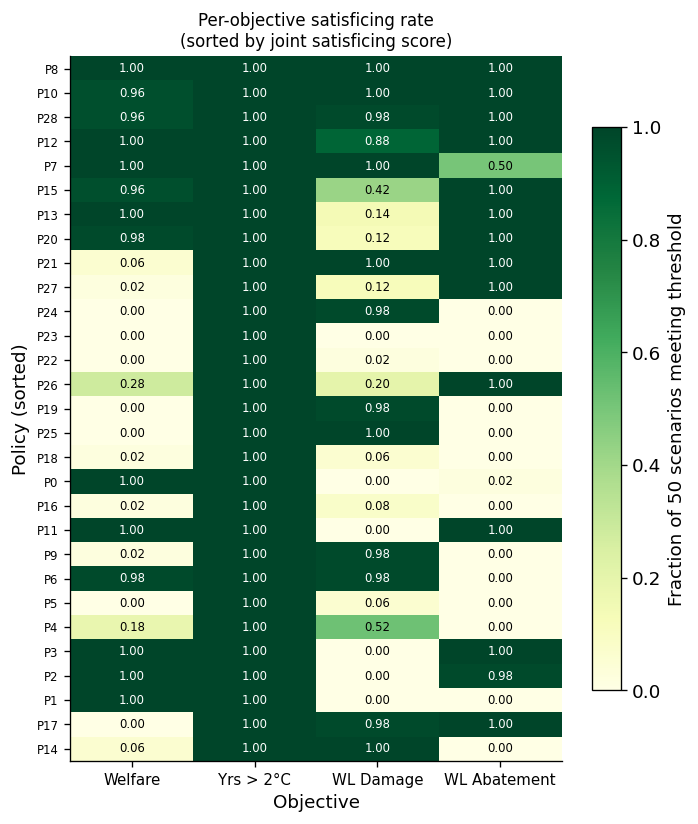

Figure saved: plots/a07_satisficing_heatmap.png


In [8]:
def _draw_heatmap(ax, data, cmap, vmin, vmax, row_labels, col_labels, title, cbar_label):
    """imshow-based heatmap (avoids seaborn/matplotlib 3.14 deepcopy incompatibility)."""
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation="nearest")
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=7)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            tc = "white" if v > (vmax - vmin) * 0.6 + vmin else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color=tc)
    plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)
    ax.set_title(title, fontsize=10)


# ── Figure 1: Satisficing heatmap ─────────────────────────────────────────────
# Per-policy per-objective satisficing rate (fraction of scenarios meeting threshold)
per_obj_sat = np.nanmean(
    results <= thresholds[np.newaxis, np.newaxis, :], axis=1
)  # shape (n_policies, n_objectives)

# Sort policies by joint satisficing score (descending)
sat_order = np.argsort(-sat_score)

fig, ax = plt.subplots(figsize=(6, 7))
_draw_heatmap(
    ax, per_obj_sat[sat_order], "YlGn", 0, 1,
    [f"P{sat_order[i]}" for i in range(N_POLICIES)], OBJ_LABELS,
    "Per-objective satisficing rate\n(sorted by joint satisficing score)",
    "Fraction of 50 scenarios meeting threshold",
)
ax.set_xlabel("Objective")
ax.set_ylabel("Policy (sorted)")
plt.tight_layout()
display(fig)
plt.savefig(os.path.join(_PLOTS_DIR, "a07_satisficing_heatmap.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Figure saved: plots/a07_satisficing_heatmap.png")

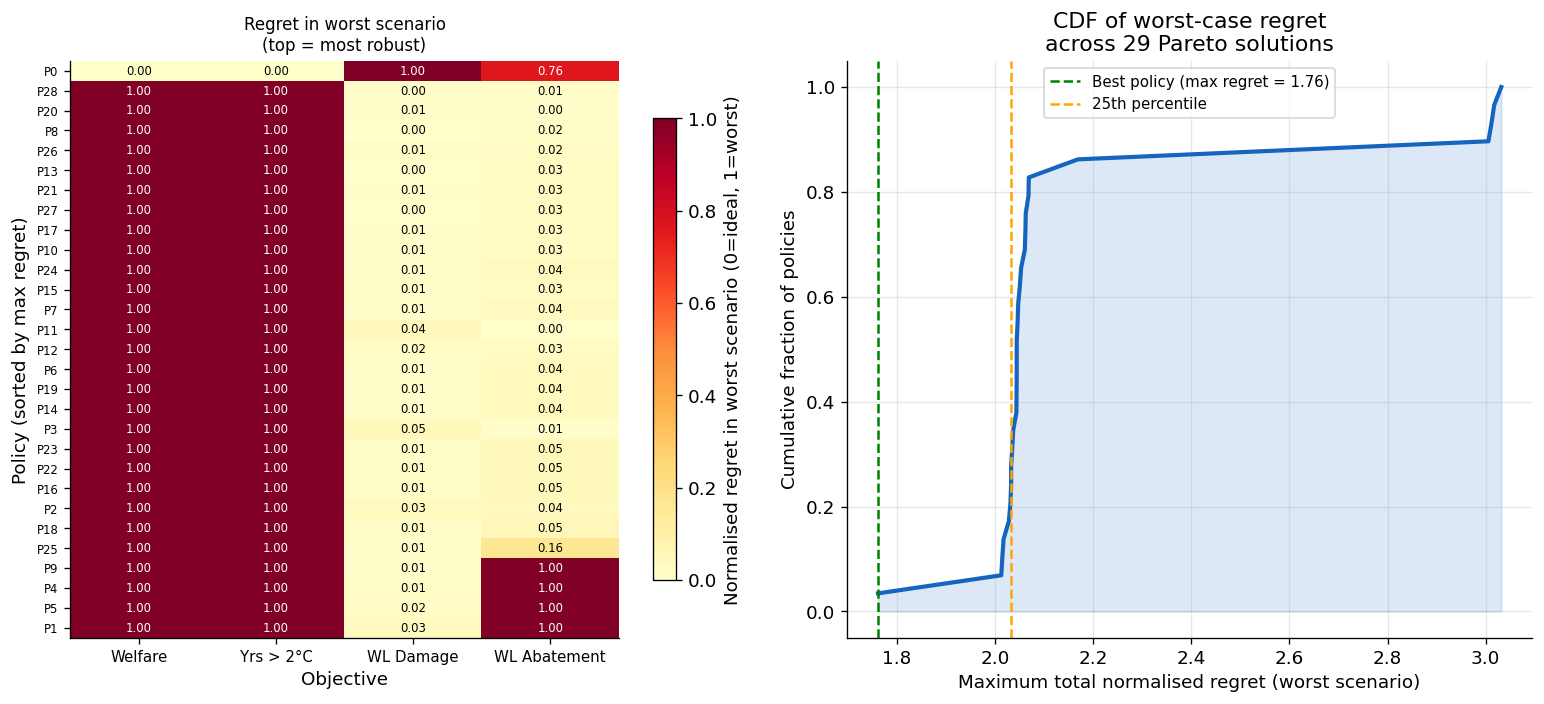

Figure saved: plots/a07_regret.png


In [9]:
# ── Figure 2: Regret heatmap + CDF ───────────────────────────────────────────
# For each policy, extract regret in its worst scenario
worst_scenario_idx   = np.nanargmax(total_regret, axis=1)   # (n_policies,)
worst_regret_per_obj = regret[np.arange(N_POLICIES), worst_scenario_idx, :]
# shape (n_policies, n_objectives) — regret in the worst scenario for each policy

cdf_x = np.sort(sorted_regret)
cdf_y = np.arange(1, N_POLICIES + 1) / N_POLICIES

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

_draw_heatmap(
    axes[0], worst_regret_per_obj[sorted_idx], "YlOrRd", 0, 1,
    [f"P{sorted_idx[i]}" for i in range(N_POLICIES)], OBJ_LABELS,
    "Regret in worst scenario\n(top = most robust)",
    "Normalised regret in worst scenario (0=ideal, 1=worst)",
)
axes[0].set_xlabel("Objective")
axes[0].set_ylabel("Policy (sorted by max regret)")

# ── CDF of maximum regret ─────────────────────────────────────────────────────
axes[1].plot(cdf_x, cdf_y, color="#1565C0", linewidth=2.5)
axes[1].fill_between(cdf_x, cdf_y, alpha=0.15, color="#1565C0")
axes[1].axvline(sorted_regret[0], color="green", linestyle="--", linewidth=1.5,
                label=f"Best policy (max regret = {sorted_regret[0]:.2f})")
axes[1].axvline(np.percentile(sorted_regret, 25), color="orange",
                linestyle="--", linewidth=1.5, label="25th percentile")
axes[1].set_xlabel("Maximum total normalised regret (worst scenario)")
axes[1].set_ylabel("Cumulative fraction of policies")
axes[1].set_title(f"CDF of worst-case regret\nacross {N_POLICIES} Pareto solutions")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
display(fig)
plt.savefig(os.path.join(_PLOTS_DIR, "a07_regret.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Figure saved: plots/a07_regret.png")

### How to read the satisficing heatmap

- **Rows** are policies sorted from highest (top) to lowest (bottom) joint satisficing score.
- **Columns** are the four objectives. Each cell shows the fraction of 50 scenarios in which that policy meets that objective's threshold: dark green = meets threshold in most scenarios; pale = rarely meets it.
- **`Yrs > 2°C` is uniformly dark green (1.00) across all policies** — every policy meets the Paris-consistent climate threshold in every scenario. This objective is not the binding constraint.
- **Which columns are palest?** The binding constraints are **Welfare** and **WL Damage** — these show the most pale cells, meaning many policies fail to simultaneously achieve median welfare and median damage welfare loss. `WL Abatement` is also pale for policies at the bottom of the list. The interaction between these economic objectives drives the low joint satisficing scores.
- **Row uniformity:** policies near the top of the sorted list have uniformly dark green across all four columns (good on most objectives in most scenarios); policies near the bottom have pale cells in welfare and/or WL Damage (fail on those objectives across many scenarios).

### How to read the regret heatmap and CDF

- **Regret heatmap rows** are the per-policy regret values *in their worst scenario* — not averaged, but the single worst case. Robust policies (top group) have pale rows even in their worst case; fragile policies (bottom group) have at least one very dark cell, meaning they perform catastrophically on that objective in some scenario.
- **CDF:** the x-axis is worst-case total regret (sum of 4 normalised regrets in the worst scenario out of 50). The y-axis is the fraction of policies at or below that regret level. A steep early rise would indicate most policies are similarly robust; a gradual slope indicates genuine spread in robustness across the Pareto front.
- **The green dashed line** marks the minimax-regret policy. Policies to its left are not shown because it is already the best.

---

## Step 6 — The most robust policy

The minimax-regret policy is the one that minimises the worst-case disappointment across all 50 scenarios.

In [10]:
best_pi = sorted_idx[0]
best_row = ref_set.iloc[best_pi]

print("Most robust policy (minimax regret):")
print(f"  Policy index          : {best_pi}")
print(f"  Max regret            : {max_regret[best_pi]:.4f}")
print(f"  Satisficing score     : {sat_score[best_pi]:.1%}  "
      f"(satisfices all thresholds in {sat_score[best_pi]*N_SCENARIOS:.0f}/{N_SCENARIOS} scenarios)")
print()

# Mean objective values across all 50 scenarios
mean_obj = np.nanmean(results[best_pi, :, :], axis=0)   # shape (n_objectives,)
std_obj  = np.nanstd( results[best_pi, :, :], axis=0)
front_median = np.nanmedian(results.reshape(-1, N_OBJECTIVES), axis=0)

print("Objective values across the 50 scenarios (mean ± std) vs. Pareto-front median:")
print(f"  {'Objective':<30s}  {'Mean':>10s}  {'Std':>8s}  {'Median (all)':>13s}  {'Diff (%)':>9s}")
print("  " + "-" * 78)
for name, label, mu, sd, med in zip(OBJECTIVES, OBJ_LABELS, mean_obj, std_obj, front_median):
    diff = (mu - med) / (abs(med) + 1e-12) * 100
    print(f"  {label:<30s}  {mu:>10.2f}  {sd:>8.2f}  {med:>13.2f}  {diff:>+9.1f}%")

Most robust policy (minimax regret):
  Policy index          : 0
  Max regret            : 1.7614
  Satisficing score     : 0.0%  (satisfices all thresholds in 0/50 scenarios)

Objective values across the 50 scenarios (mean ± std) vs. Pareto-front median:
  Objective                             Mean       Std   Median (all)   Diff (%)
  ------------------------------------------------------------------------------
  Welfare                             857.40    487.93        1177.62      -27.2%
  Yrs > 2°C                           283.12      5.07         284.00       -0.3%
  WL Damage                           207.92    482.81         135.06      +53.9%
  WL Abatement                      21972.54   2123.53       11478.83      +91.4%


### Interpreting the most robust policy

The minimax-regret policy is **not the best on any single objective** — that would make it an extreme of the Pareto front, not a balanced interior solution. Instead, it achieves:

- **`years_above_2C` below the Pareto-front median** — it achieves meaningful climate protection without being the most aggressive policy.
- **`welfare_loss_abatement` near or below the median** — it does not pay the highest abatement cost.
- **`welfare` near the median** — welfare is nearly invariant across the Pareto front; it discriminates little between policies.
- **A satisficing score that is above zero** — it meets all thresholds simultaneously in at least some futures, unlike the most extreme Pareto solutions.

A risk-averse decision-maker prefers this policy because, *under any of the 50 climate futures, this policy never performs catastrophically badly relative to what was achievable in that future*.

#### Caveats to communicate clearly

1. **Equal weighting assumed.** Total regret sums four objectives with equal weight. A decision-maker who cares much more about climate risk should weight `years_above_2C` more heavily — this would shift the optimal selection toward more climate-aggressive policies.
2. **Scenario coverage is finite.** 50 FAIR members span much more uncertainty than the 10 used during optimisation, but not all 1 000 possible members. A different draw of 50 would give slightly different regret scores.
3. **Pareto front scope.** The reference set was generated by optimising under the Utilitarian welfare function. Policies that are robust under Utilitarian may not be robust under a different welfare function, and the latter's Pareto front was never explored.

---

## Reflection Questions — Model Answers

**1. Why use 50 FAIR ensemble members for re-evaluation rather than the 10 used during optimisation?**

> The 10 members used during optimisation were a computational proxy: using more would make each function evaluation too slow for the MOEA. The 10 members provided enough signal to guide the search toward non-dominated solutions, but they are too few to characterise the *distribution* of performance under uncertainty. With 50 members we see whether a policy that looked robust under the 10-member proxy actually performs well across a wider range of climate trajectories. The more scenarios used in re-evaluation, the more reliable the robustness estimates — but diminishing returns set in, and 50 members typically captures most of the rank-ordering.


**2. Why is the satisficing score typically low (e.g., 10–30%) even for the best policies?**

> Because the median threshold is applied *jointly* across all four objectives, and the objectives trade off with each other. In any given scenario, a policy that meets the climate threshold (low `years_above_2C`) tends to have high abatement cost (high `welfare_loss_abatement`), exceeding the abatement threshold. Satisficing all four simultaneously is therefore rare. This low score is not a model failure — it is the quantitative signature of genuine multi-objective conflict projected onto climate uncertainty.


**3. Which single policy would you recommend, and why?**

> The minimax-regret policy (lowest maximum regret across the 50 scenarios) is the recommended choice for a risk-averse decision-maker. It performs acceptably in the most climate futures, never catastrophically in any. Caveats: (a) equal objective weighting was assumed — a decision-maker with strong preferences should re-weight; (b) the reference set was generated under the Utilitarian welfare function — robustness under a different welfare framework was not assessed; (c) the recommendation is conditioned on the 50-member scenario set — increasing to 200 members would give higher confidence in the rank ordering.